# Classical Machine Learning: Part 4
## Support Vector Machines (SVMs) (MNIST Dataset Classification)

An SVM tries to find the best-fitting hyperplane that separates data points of different classes with the widest possible margin. 

Loading MNIST dataset...
Dataset shape: (70000, 784)
Labels shape: (70000,)
No. of classes: 10


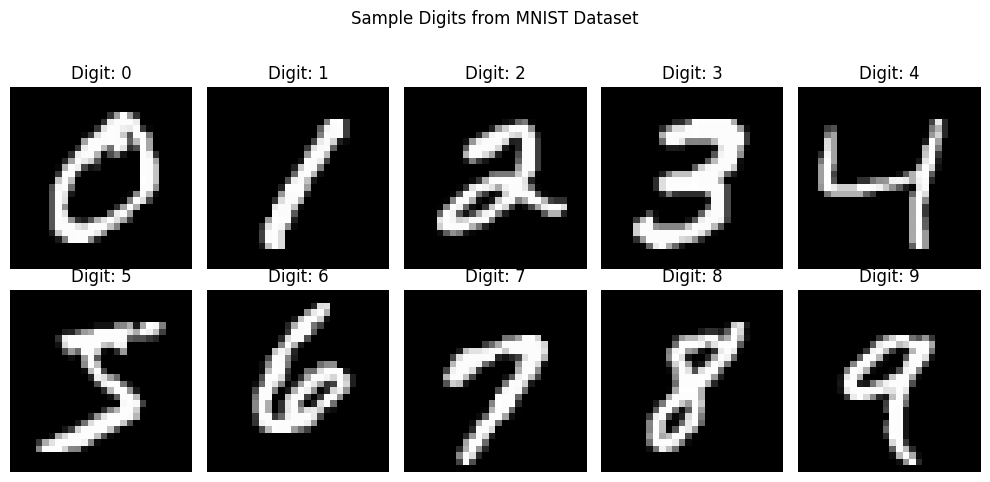

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

print('Loading MNIST dataset...')
mnist=fetch_openml('mnist_784', as_frame=False, parser='auto')

X, y= mnist['data'], mnist['target']
X=X.astype(int)
y=y.astype(int)

print(f'Dataset shape: {X.shape}')
print(f'Labels shape: {y.shape}')
print(f'No. of classes: {len(np.unique(y))}')

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    image=X[y==i][0].reshape(28,28)
    plt.imshow(image, cmap='gray')
    plt.title(f'Digit: {i}')
    plt.axis('off')
plt.tight_layout()
plt.suptitle('Sample Digits from MNIST Dataset')
plt.subplots_adjust(top=0.85)
plt.show()

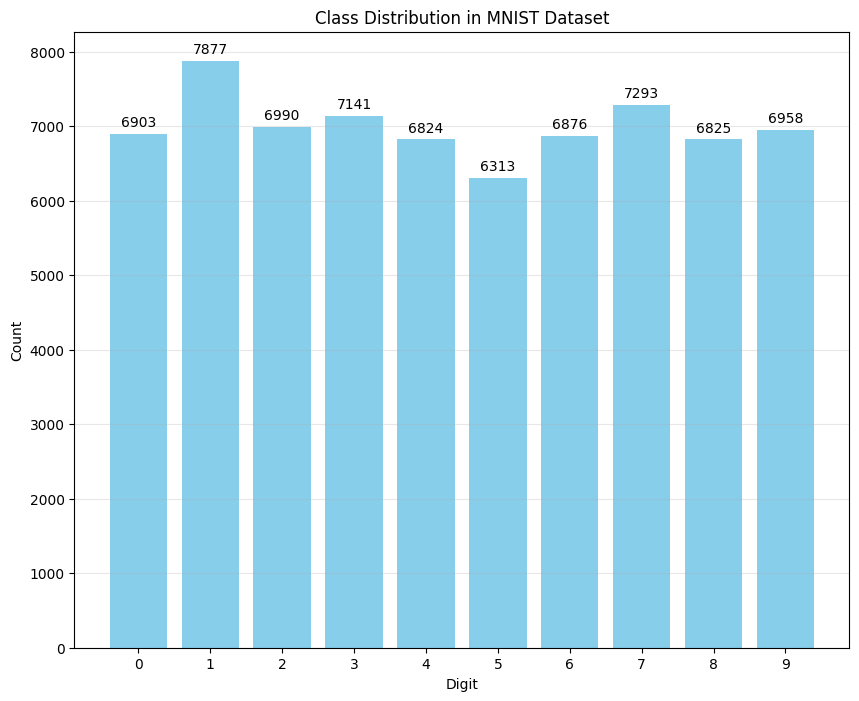

In [2]:
plt.figure(figsize=(10,8))
digit_counts=np.bincount(y)
plt.bar(range(10), digit_counts, color='skyblue')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Class Distribution in MNIST Dataset')
plt.xticks(range(10))
for i,count in enumerate(digit_counts):
    plt.text(i, count+100, str(count), ha='center')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

X_scaled=scaler.fit_transform(X)

print(f'Min value after scaling: {X_scaled.min()}')
print(f'Max value after scaling: {X_scaled.max()}')

Min value after scaling: 0.0
Max value after scaling: 1.0


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.1,random_state=42)

print(f'Training data shape: {X_train.shape}')
print(f'Testing data shape: {X_test.shape}')

Training data shape: (63000, 784)
Testing data shape: (7000, 784)


In [ ]:
from sklearn.svm import SVC

print('Training SVM Model...')
svm_calf=SVC(kernel='linear')

svm_calf.fit(X_train, y_train)
print('Model training complete!')

Training SVM Model...


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print('Making predictions on test data...')
y_pred=svm_calf.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)
print(f'SVM Model Accuracy: {accuracy:.4f}')

print('Classification report:')
print(classification_report(y_test, y_pred))

In [ ]:
def plot_digit(data):
    image=data.reshape(28,28)
    plt.imshow(image, cmap=plt.cm.hot, interpolation='nearest')
    plt.axis('off')

print('Visualising a sample digit...')
some_digit=X[0]
plot_digit(some_digit)
plt.title(f'Digit: {y[0]}')
plt.show()

from sklearn.decomposition import PCA

pca=PCA(n_components=2)
X_reduced=pca.fit_transform(X_scaled)

svm_2d=SVC(kernel='linear')
svm_2d.fit(X_reduced[:10000], y[:10000])

h=0.02
x_min, x_max=X_reduced[:,0].min()-1, X_reduced[:,0].max()+1


plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_reduced[:5000,0], X_reduced[:5000,1], c=y[:5000], edgecolor='k', s=20)
plt.title('SVM Decision Boundaries for MNIST (2D Projection):')
plt.xlabel('Principal Component 1')
plt.yalbel('Principal Component 2')
plt.colorbar()
plt.show()